# 04 — Security-aware evaluation

Compare the baseline (LR + TF-IDF) and the hybrid (LightGBM + TF-IDF + handcrafted) with **security-aware metrics**, not just accuracy:

- **FPR @ fixed TPR** — in a phishing filter, missing phish is bad but flagging real   bank sites is also bad; we care about FPR at high recall.
- **PR-AUC** — more informative than ROC-AUC on imbalanced detection problems.
- **Calibration** — does `predict_proba` reflect real probability?
- **High-confidence errors** — where does each model fail badly?

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix)
from sklearn.model_selection import train_test_split

from features import extract_lexical_features, FEATURE_NAMES

RANDOM_STATE = 42
PROCESSED = Path('../data/processed/phiusiil_clean.parquet')
MODELS = Path('../models')

## Recreate the identical test split

In [2]:
df = pd.read_parquet(PROCESSED)
X_urls, y = df['URL'].astype(str).to_numpy(), df['label'].to_numpy()
_, X_tmp, _, y_tmp = train_test_split(
    X_urls, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
_, X_te, _, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)
print('Test size:', len(X_te))

Test size: 35306


## Load both models + score test set

In [3]:
baseline = joblib.load(MODELS / 'baseline_lr_tfidf.joblib')
hybrid   = joblib.load(MODELS / 'hybrid_lgbm.joblib')

# Baseline: sklearn Pipeline takes raw URLs
p_base = baseline.predict_proba(X_te)[:, 1]

# Hybrid: manual featurize -> vectorize -> scale -> hstack -> predict
F_te = pd.DataFrame([extract_lexical_features(u) for u in X_te],
                    columns=FEATURE_NAMES).astype(np.float32)
T_te = hybrid['vectorizer'].transform(X_te)
F_te_s = hybrid['scaler'].transform(F_te)
X_te_h = hstack([T_te, csr_matrix(F_te_s)]).tocsr()
p_hyb = hybrid['classifier'].predict_proba(X_te_h)[:, 1]

C:\Users\clark\OneDrive\Documents\GitHub\cybersecurity-finals\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Standard metrics — side-by-side

In [4]:
rows = []
for name, p in [('baseline (LR+TFIDF)', p_base), ('hybrid (LGBM)', p_hyb)]:
    pred = (p >= 0.5).astype(int)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_te, pred),
        'roc_auc':  roc_auc_score(y_te, p),
        'pr_auc':   average_precision_score(y_te, p),
    })
pd.DataFrame(rows).set_index('model').round(4)

,accuracy,roc_auc,pr_auc
model,,,
baseline (LR+TFIDF),0.9970,0.9992,0.9989
hybrid (LGBM),0.9982,0.9990,0.9988


## FPR at fixed TPR (security-aware)

Lower is better. FPR @ TPR=0.99 says: *if we want to catch 99% of phishing URLs, what fraction of legit URLs do we wrongly flag?*

In [5]:
def fpr_at_tpr(y_true, score, tpr_target):
    # NOTE: in this dataset label=1 is legit, label=0 is phish.
    # We want the positive class to be phish, so invert.
    y_phish = 1 - y_true
    s_phish = 1 - score
    fpr, tpr, _ = roc_curve(y_phish, s_phish)
    idx = np.searchsorted(tpr, tpr_target)
    idx = min(idx, len(fpr) - 1)
    return float(fpr[idx])

rows = []
for name, p in [('baseline', p_base), ('hybrid', p_hyb)]:
    rows.append({
        'model': name,
        'FPR@TPR=0.95': fpr_at_tpr(y_te, p, 0.95),
        'FPR@TPR=0.99': fpr_at_tpr(y_te, p, 0.99),
    })
pd.DataFrame(rows).set_index('model').round(5)

,FPR@TPR=0.95,FPR@TPR=0.99
model,,
baseline,0.0,0.0
hybrid,0.0,0.0


## ROC + Precision-Recall curves

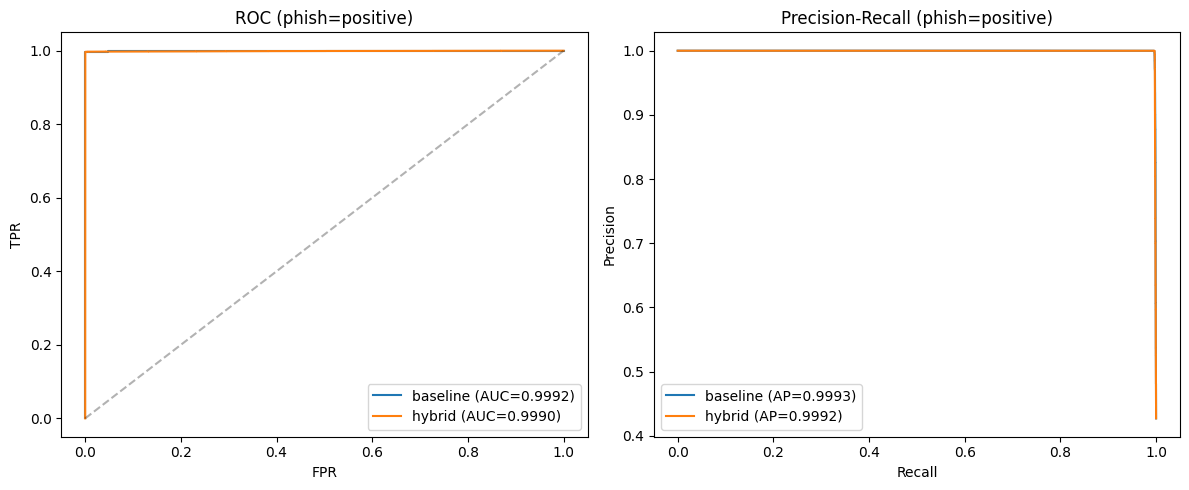

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, p in [('baseline', p_base), ('hybrid', p_hyb)]:
    y_phish = 1 - y_te
    s_phish = 1 - p
    fpr, tpr, _ = roc_curve(y_phish, s_phish)
    pr,  rc,  _ = precision_recall_curve(y_phish, s_phish)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_phish, s_phish):.4f})')
    axes[1].plot(rc, pr,  label=f'{name} (AP={average_precision_score(y_phish, s_phish):.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC (phish=positive)')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall (phish=positive)')
for ax in axes: ax.legend()
plt.tight_layout(); plt.show()

## Calibration

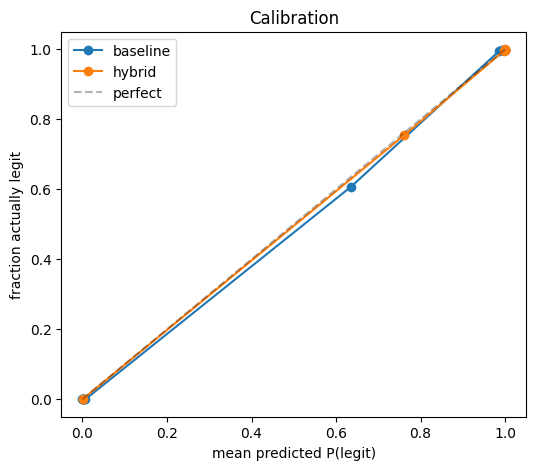

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, p in [('baseline', p_base), ('hybrid', p_hyb)]:
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=15, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 'o-', label=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='perfect')
ax.set(xlabel='mean predicted P(legit)', ylabel='fraction actually legit',
       title='Calibration')
ax.legend(); plt.show()

## Confusion matrices @ threshold 0.5

In [8]:
for name, p in [('baseline', p_base), ('hybrid', p_hyb)]:
    cm = confusion_matrix(y_te, (p >= 0.5).astype(int))
    print(f'\n{name}:')
    print(pd.DataFrame(cm,
          index=['true_phish', 'true_legit'],
          columns=['pred_phish', 'pred_legit']))


baseline:
            pred_phish  pred_legit
true_phish       14973         105
true_legit           0       20228

hybrid:
            pred_phish  pred_legit
true_phish       15016          62
true_legit           1       20227


## Most-confident errors

Top URLs where the hybrid model was *very* confident but wrong — useful for the thesis discussion of failure modes.

In [9]:
err_df = pd.DataFrame({'url': X_te, 'true': y_te, 'p_legit_hybrid': p_hyb})
# false phish: predicted phish (low p_legit) but actually legit
fp = err_df[(err_df['true'] == 1) & (err_df['p_legit_hybrid'] < 0.5)] \
        .sort_values('p_legit_hybrid').head(10)
# false legit: predicted legit (high p_legit) but actually phish
fn = err_df[(err_df['true'] == 0) & (err_df['p_legit_hybrid'] >= 0.5)] \
        .sort_values('p_legit_hybrid', ascending=False).head(10)
print('=== Most-confident FALSE PHISH (legit flagged as phish) ===')
print(fp.to_string(index=False))
print('\n=== Most-confident MISSED PHISH (phish flagged as legit) ===')
print(fn.to_string(index=False))

=== Most-confident FALSE PHISH (legit flagged as phish) ===
                                            url  true  p_legit_hybrid
https://www.revista-estudios.revistas.deusto.es     1        0.359582

=== Most-confident MISSED PHISH (phish flagged as legit) ===
                             url  true  p_legit_hybrid
            https://www.cuag.fit     0        0.999571
 https://www.capitalcomputer.com     0        0.999536
        https://www.eventsreg.in     0        0.999531
      https://www.estilmenut.com     0        0.999498
    https://www.pentahousing.com     0        0.999479
https://www.johnrichardjones.com     0        0.999468
          https://www.metanfo.fr     0        0.999447
    https://www.uknypxl-rqf-3.ml     0        0.999406
        https://www.pastance.com     0        0.999387
     https://www.farsanteaban.tk     0        0.999363
